In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Load the dataset
df = pd.read_csv("../data/Ecommerce Customers")

# Display the first 5 rows
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [2]:
# Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [3]:
# Statistical summary of numerical columns
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [4]:
# Check for missing values
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [5]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
# Select features and target

X = df[
    [
        "Avg. Session Length",
        "Time on App",
        "Time on Website",
        "Length of Membership"
    ]
]

y = df["Yearly Amount Spent"]

# Display the features
X.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308


In [7]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 4)
Testing data: (100, 4)


In [8]:
# Single-feature Linear Regression
# Using only Time on App

X_single = df[["Time on App"]]

X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
    X_single, y,
    test_size=0.20,
    random_state=42
)

single_model = LinearRegression()
single_model.fit(X_train_single, y_train_single)

y_pred_single = single_model.predict(X_test_single)

# Evaluate the model
single_rmse = np.sqrt(mean_squared_error(y_test_single, y_pred_single))
single_r2 = r2_score(y_test_single, y_pred_single)

print("Single-Feature Linear Regression")
print("RMSE:", round(single_rmse, 4))
print("R² Score:", round(single_r2, 4))

Single-Feature Linear Regression
RMSE: 64.213
R² Score: 0.1673


In [9]:
# Multiple Linear Regression using all selected features

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

# Make predictions
y_pred_multiple = multiple_model.predict(X_test)

# Evaluate the model
multiple_rmse = np.sqrt(mean_squared_error(y_test, y_pred_multiple))
multiple_r2 = r2_score(y_test, y_pred_multiple)

print("Multiple Linear Regression")
print("RMSE:", round(multiple_rmse, 4))
print("R² Score:", round(multiple_r2, 4))

Multiple Linear Regression
RMSE: 10.4816
R² Score: 0.9778


In [10]:
# Compare Single-Feature and Multiple Linear Regression

comparison = pd.DataFrame({
    "Model": [
        "Single Feature (Time on App)",
        "Multiple Features (All 4)"
    ],
    "RMSE": [
        single_rmse,
        multiple_rmse
    ],
    "R² Score": [
        single_r2,
        multiple_r2
    ]
})

comparison

,Model,RMSE,R² Score
0,Single Feature (Time on App),64.213030,0.167299
1,Multiple Features (All 4),10.481591,0.977813


In [11]:
# Display model coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
3,Length of Membership,61.896829
1,Time on App,38.785346
0,Avg. Session Length,25.596259
2,Time on Website,0.310386


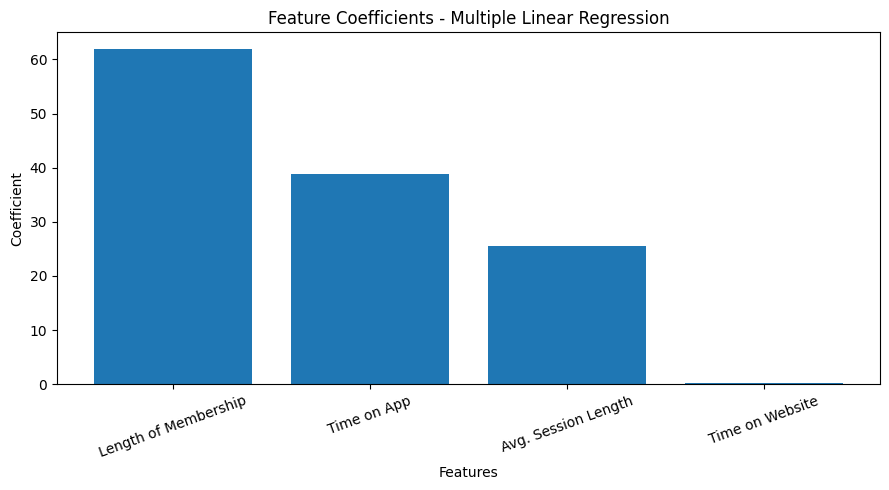

In [12]:
# Visualize feature coefficients

plt.figure(figsize=(9, 5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Coefficients - Multiple Linear Regression")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

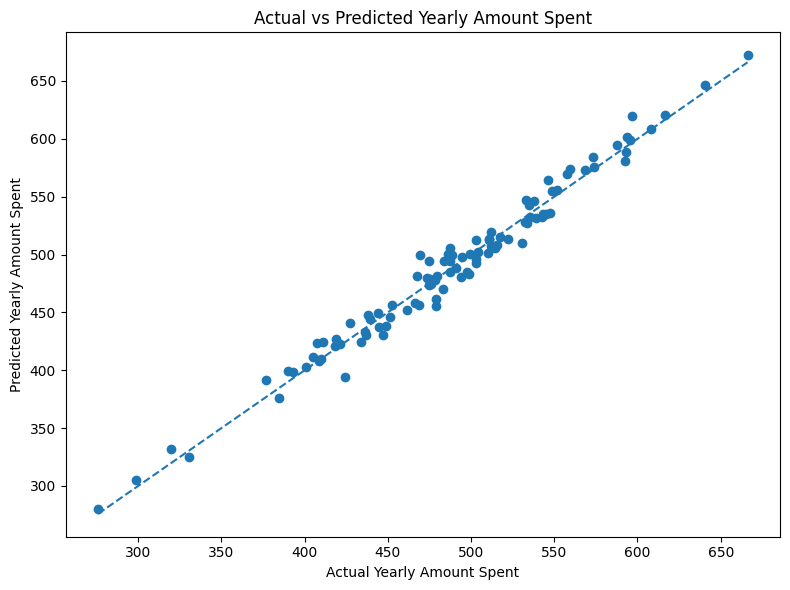

In [13]:
# Plot Actual vs Predicted values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_multiple)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Yearly Amount Spent")
plt.ylabel("Predicted Yearly Amount Spent")
plt.title("Actual vs Predicted Yearly Amount Spent")

plt.tight_layout()
plt.show()

In [14]:
# Save the best model

model_path = "../models/multiple_linear_regression_model.pkl"

joblib.dump(multiple_model, model_path)

print("Model saved successfully at:", model_path)

Model saved successfully at: ../models/multiple_linear_regression_model.pkl


In [15]:
# Example predictions

example_predictions = pd.DataFrame({
    "Actual Yearly Amount Spent": y_test.iloc[:10].values,
    "Predicted Yearly Amount Spent": y_pred_multiple[:10]
})

example_predictions["Difference"] = (
    example_predictions["Actual Yearly Amount Spent"]
    - example_predictions["Predicted Yearly Amount Spent"]
)

example_predictions.round(2)

,Actual Yearly Amount Spent,Predicted Yearly Amount Spent,Difference
0,401.03,402.86,-1.83
1,534.78,542.53,-7.76
2,418.60,426.62,-8.02
3,503.98,501.91,2.06
4,410.07,409.67,0.40
5,557.61,569.92,-12.31
6,538.94,531.50,7.44
7,514.34,505.94,8.39
8,408.62,408.10,0.52
9,475.02,473.46,1.56


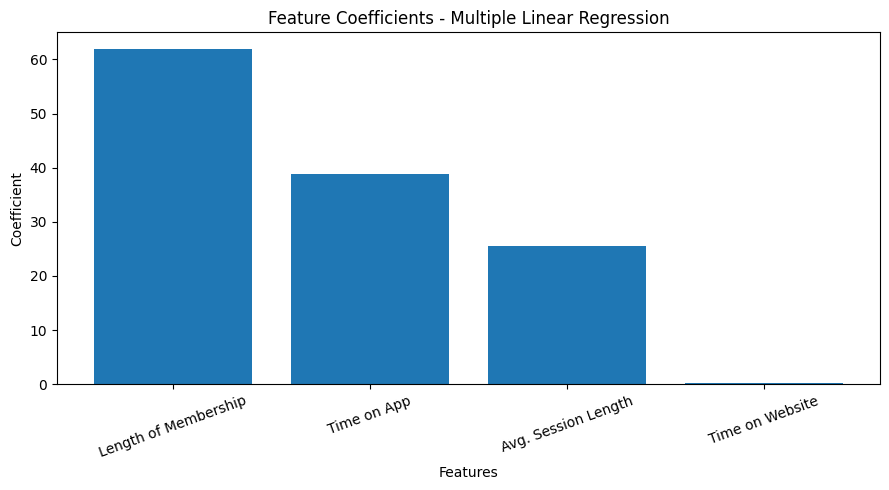

In [16]:
# Visualize and save feature coefficients

plt.figure(figsize=(9, 5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Coefficients - Multiple Linear Regression")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("../outputs/feature_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

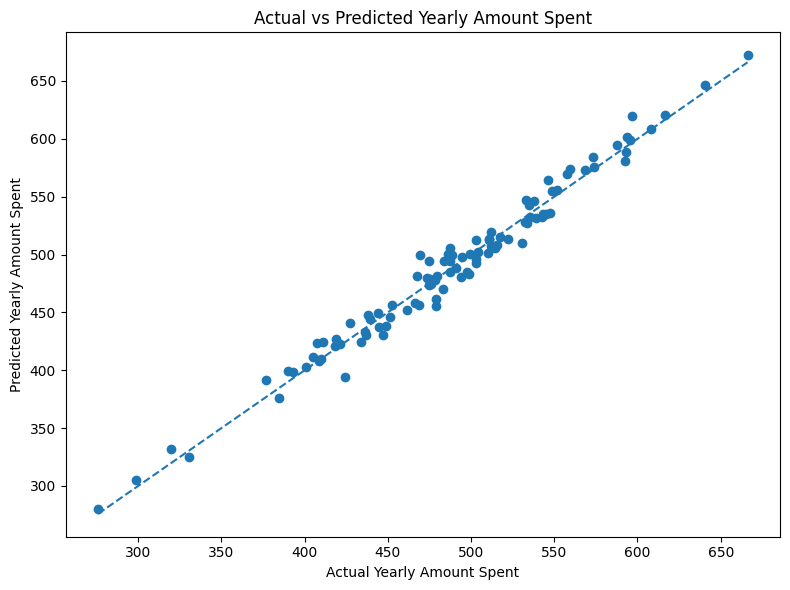

In [17]:
# Plot and save Actual vs Predicted values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_multiple)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Yearly Amount Spent")
plt.ylabel("Predicted Yearly Amount Spent")
plt.title("Actual vs Predicted Yearly Amount Spent")

plt.tight_layout()

plt.savefig(
    "../outputs/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()